# Clase de Procesamiento de Imágenes

In [1]:
from PIL import Image

In [2]:
img = Image.open("data/img_cat.jpeg")

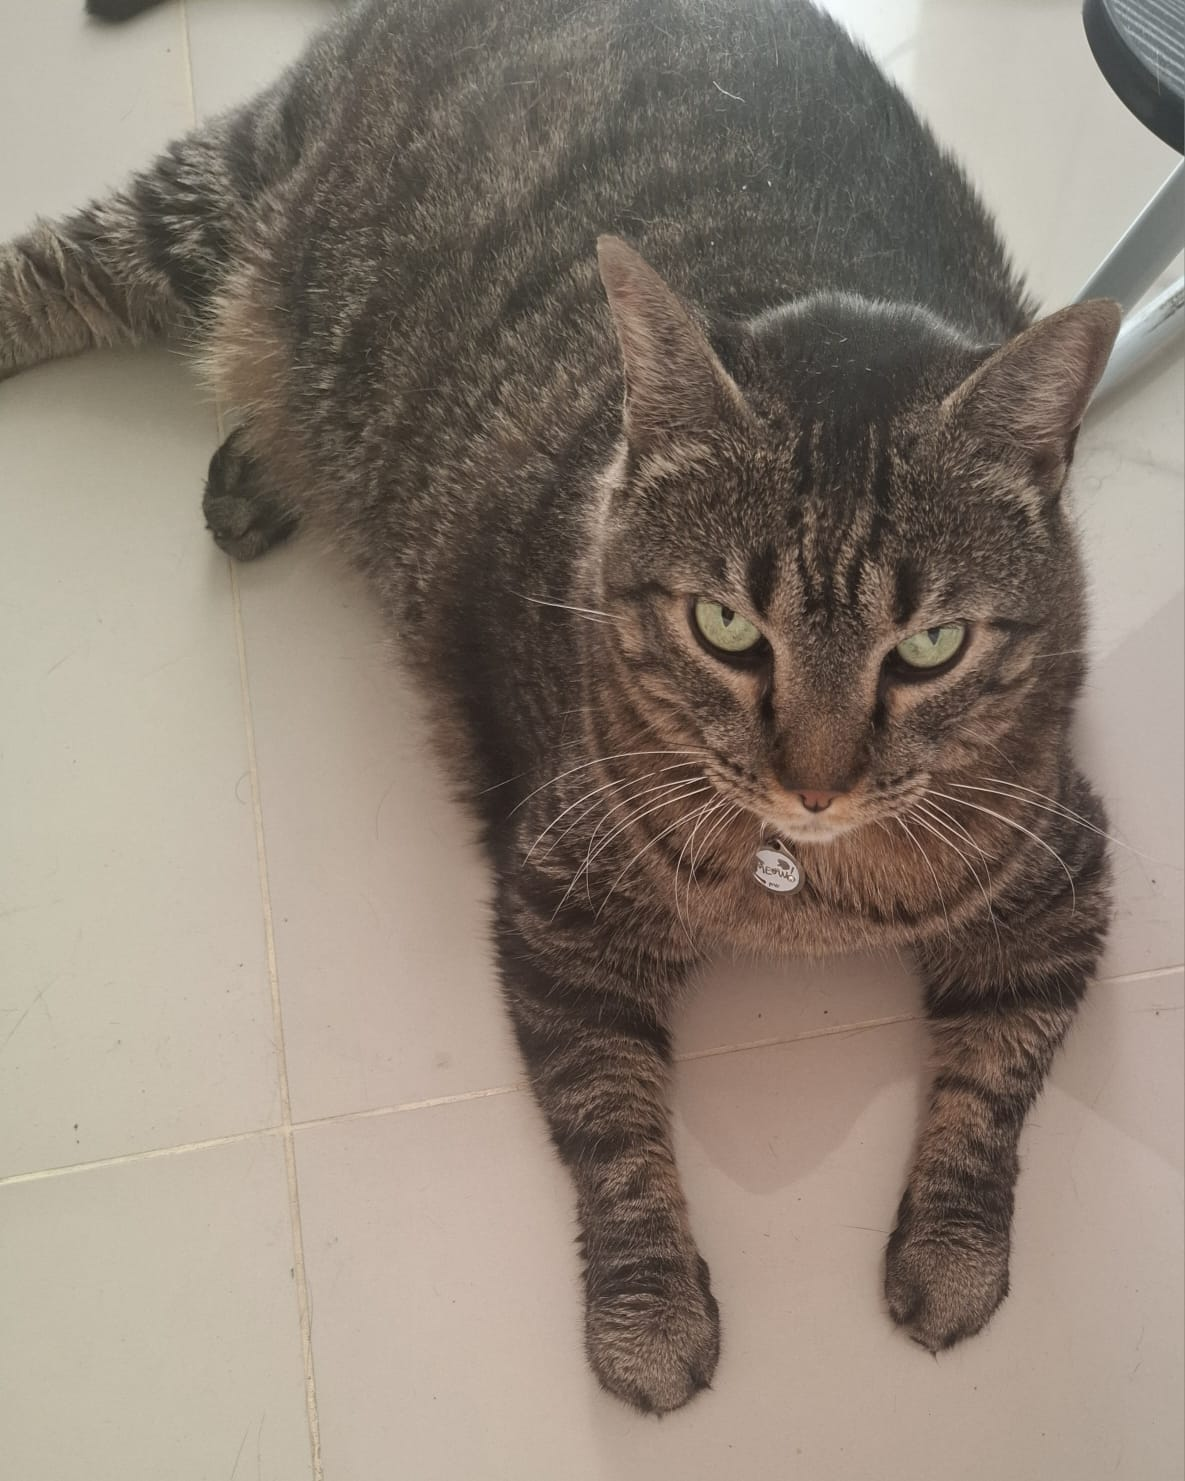

In [3]:
display(img)

In [4]:
img.size

(1185, 1481)

In [5]:
import numpy as np
arr = np.array(img)

In [6]:
arr.shape

(1481, 1185, 3)

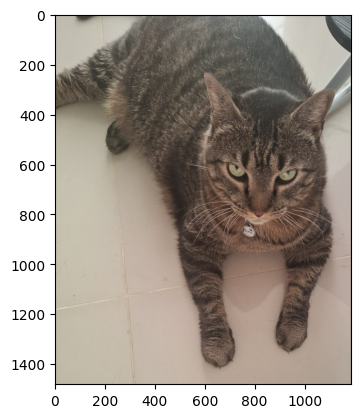

In [8]:
import matplotlib.pyplot as plt
plt.imshow(arr) 

In [12]:
arr[800,800,:] = 255

In [13]:
arr[800,800,:] 

array([255, 255, 255], dtype=uint8)

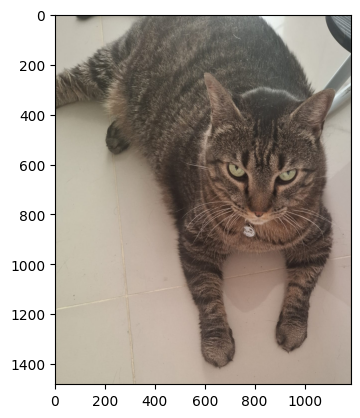

In [14]:
plt.imshow(arr)

In [15]:
arr[:,800,:] = 255

In [16]:
arr[145,800,:]

array([255, 255, 255], dtype=uint8)

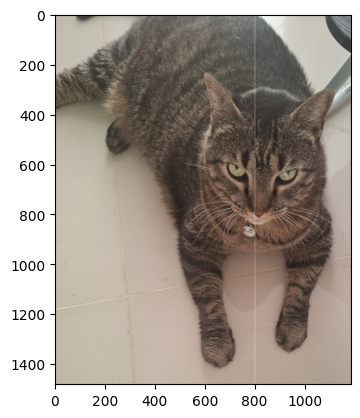

In [17]:
plt.imshow(arr)

In [20]:
arr[:,800:820,:] = (0,255,0)

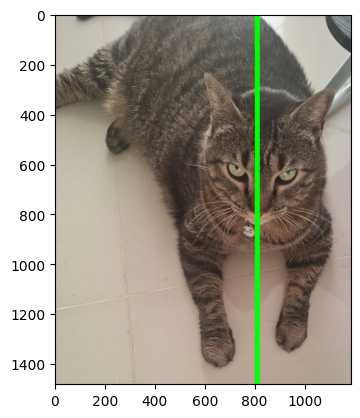

In [21]:
plt.imshow(arr)

In [22]:
arr[:,:,0] = 0

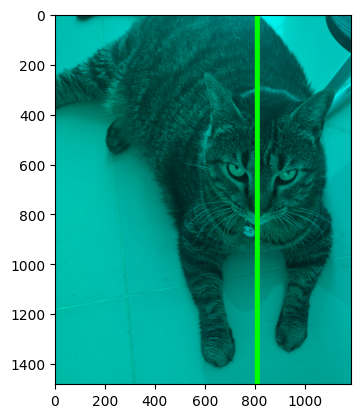

In [23]:
plt.imshow(arr)

In [24]:
arr[:,:,2] = 0

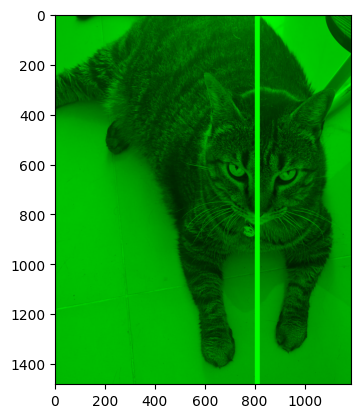

In [25]:
plt.imshow(arr)

In [13]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

In [3]:
img = Image.open("data/img_cat.jpeg")

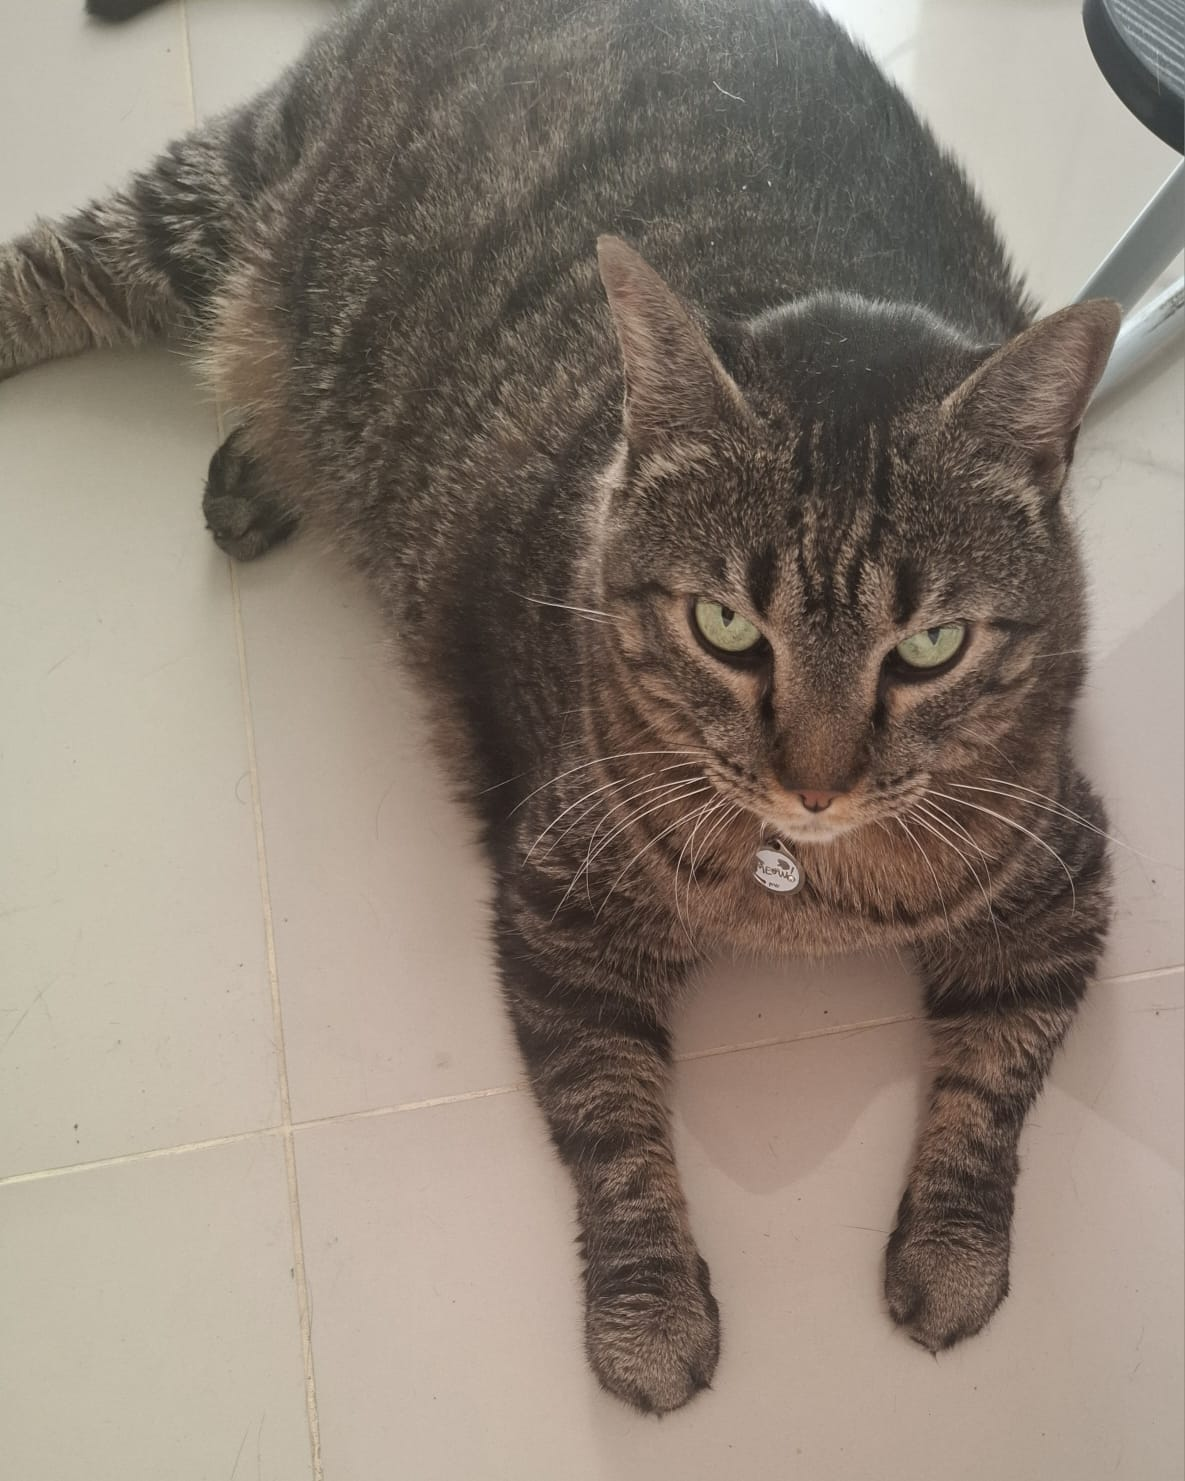

In [5]:
display(img)

In [6]:
img.size

(1185, 1481)

In [7]:
arr = np.array(img)

In [9]:
arr.shape

(1481, 1185, 3)

In [11]:
Ir = arr[:,:,0]
Ig = arr[:,:,1] 
Ib = arr[:,:,2]
Iprom = (1/3)*Ir + (1/3)*Ig + (1/3)*Ib

In [12]:
Ict = np.stack((Iprom, Iprom, Iprom), axis=2).astype(np.uint8)  

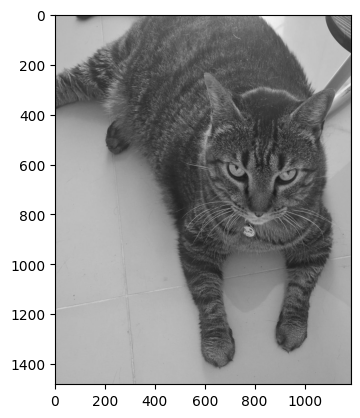

In [14]:
plt.imshow(Ict)

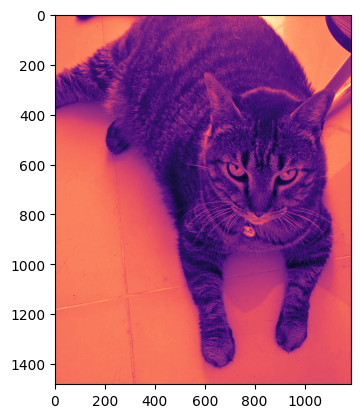

In [18]:
plt.imshow(Iprom, cmap='magma')

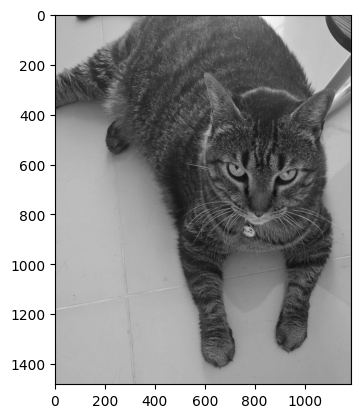

In [19]:
plt.imshow(Iprom, cmap='gray')

In [23]:
Iprom = Iprom.astype(np.uint8)
Ipromflat = Iprom.flatten()

In [28]:
Ipromflat.shape

(1754985,)

In [27]:
np.unique(Ipromflat)

array([ 14,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,  27,
        28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,  40,
        41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,  53,
        54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,  65,  66,
        67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,  78,  79,
        80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,  91,  92,
        93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103, 104, 105,
       106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118,
       119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131,
       132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144,
       145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157,
       158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170,
       171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183,
       184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 19

In [29]:
histIprom, bin_edges = np.histogram(Ipromflat, bins=256, range=(0, 255))

<BarContainer object of 256 artists>

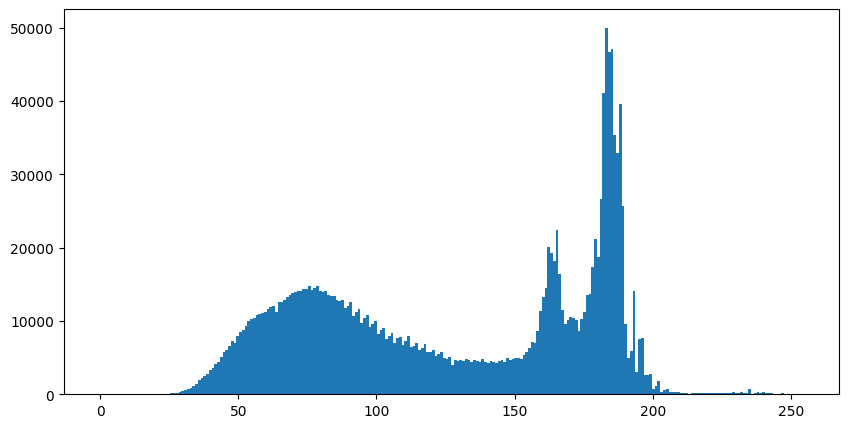

In [30]:
plt.figure(figsize=(10,5))
plt.bar(bin_edges[:-1], histIprom, width=1)

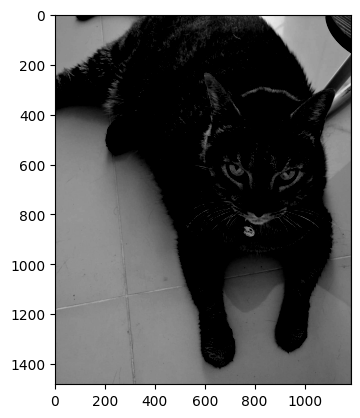

In [37]:
plt.imshow(Iprom, cmap='gray', vmin=100, vmax=255)

In [38]:
Ival = Iprom/255

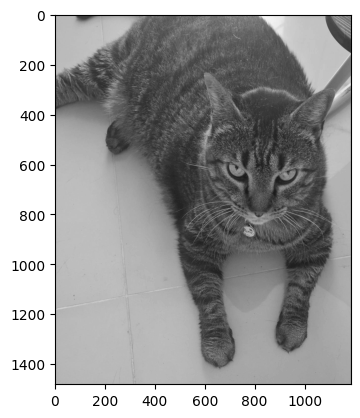

In [40]:
plt.imshow(Ival, cmap='gray', vmin=0, vmax=1)

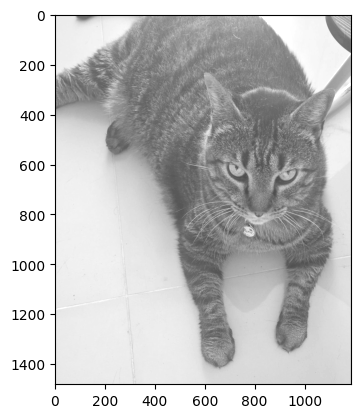

In [ ]:
Io1 = Ival+0.2
plt.imshow(Io1, cmap='gray', vmin=0, vmax=1)

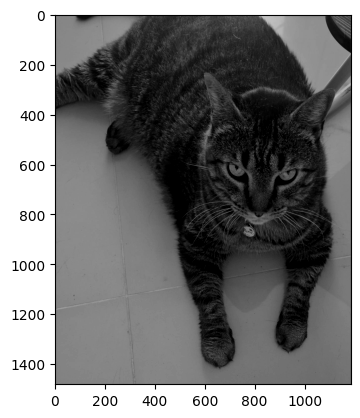

In [42]:
Io2 = Ival-0.2
plt.imshow(Io2, cmap='gray', vmin=0, vmax=1)

Text(0.5, 1.0, 'I - 0.2')

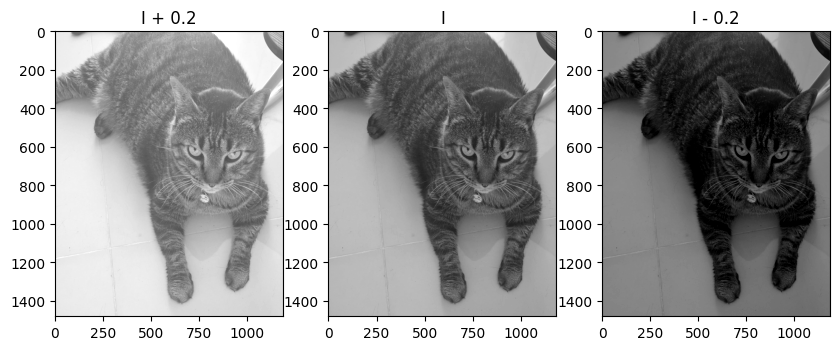

In [43]:
plt.figure(figsize=(10,5))
plt.subplot(1,3,1)
plt.imshow(Io1, cmap='gray', vmin=0, vmax=1)
plt.title('I + 0.2')
plt.subplot(1,3,2) 
plt.imshow(Ival, cmap='gray', vmin=0, vmax=1)
plt.title('I') 
plt.subplot(1,3,3)
plt.imshow(Io2, cmap='gray', vmin=0, vmax=1)
plt.title('I - 0.2')

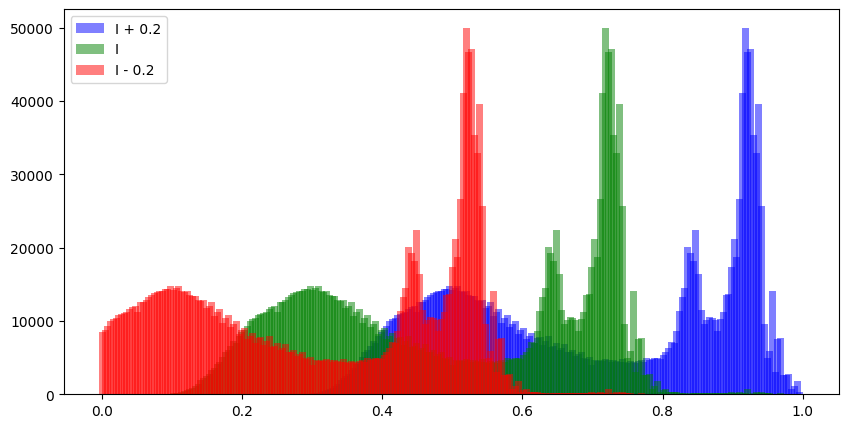

In [45]:
histIval, bin_edges = np.histogram(Ival, bins=256, range=(0, 1))
histIo1, bin_edges = np.histogram(Io1, bins=256, range=(0, 1))
histIo2, bin_edges = np.histogram(Io2, bins=256, range=(0, 1))

plt.figure(figsize=(10,5))
plt.bar(bin_edges[:-1], histIo1, width=0.01, color='blue', alpha=0.5, label='I + 0.2')
plt.bar(bin_edges[:-1], histIval, width=0.01, color='green', alpha=0.5, label='I')
plt.bar(bin_edges[:-1], histIo2, width=0.01, color='red', alpha=0.5, label='I - 0.2')
plt.legend()

# Corrección Gamma

In [5]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Cargar en escala de grises
img = Image.open("data/img_cat.jpeg").convert('L')
img_array = np.array(img)

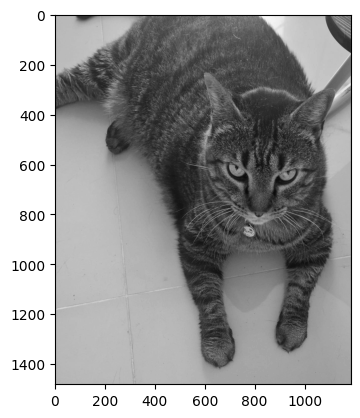

In [6]:
plt.imshow(img_array, cmap='gray')

In [7]:
img_array.shape

(1481, 1185)

(array([2.0000e+00, 3.0000e+00, 0.0000e+00, 5.0000e+00, 1.0000e+00,
        1.3000e+01, 1.4000e+01, 2.5000e+01, 3.5000e+01, 7.5000e+01,
        1.2400e+02, 1.6600e+02, 0.0000e+00, 2.1300e+02, 2.5600e+02,
        3.5900e+02, 5.0300e+02, 6.4500e+02, 8.2300e+02, 1.0640e+03,
        1.3600e+03, 1.7350e+03, 2.0700e+03, 2.4980e+03, 2.5660e+03,
        0.0000e+00, 2.9440e+03, 3.3470e+03, 3.7830e+03, 4.2840e+03,
        4.7690e+03, 5.2390e+03, 5.6920e+03, 6.2490e+03, 6.4850e+03,
        6.8830e+03, 7.2870e+03, 7.7960e+03, 0.0000e+00, 8.2040e+03,
        8.8350e+03, 9.2590e+03, 9.6390e+03, 1.0027e+04, 1.0493e+04,
        1.0554e+04, 1.0606e+04, 1.0895e+04, 1.1051e+04, 1.1212e+04,
        1.1783e+04, 0.0000e+00, 1.2055e+04, 1.2406e+04, 1.2327e+04,
        1.2547e+04, 1.3025e+04, 1.3206e+04, 1.3505e+04, 1.3812e+04,
        1.3659e+04, 1.3731e+04, 1.4001e+04, 0.0000e+00, 1.4407e+04,
        1.4230e+04, 1.4310e+04, 1.4420e+04, 1.4248e+04, 1.4370e+04,
        1.4141e+04, 1.3933e+04, 1.3660e+04, 1.35

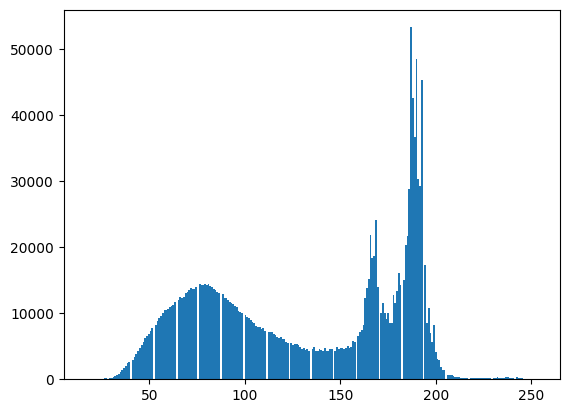

In [31]:
plt.hist(img_array.flatten(), bins=256)

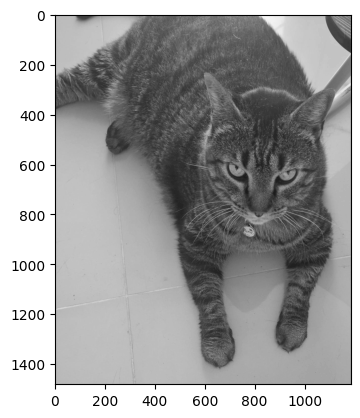

In [20]:
img_norm = img_array / 255.0
plt.imshow(img_norm, cmap='gray', vmin=0, vmax=1)

(array([2.0000e+00, 3.0000e+00, 0.0000e+00, 5.0000e+00, 1.0000e+00,
        1.3000e+01, 1.4000e+01, 2.5000e+01, 3.5000e+01, 7.5000e+01,
        1.2400e+02, 1.6600e+02, 0.0000e+00, 2.1300e+02, 2.5600e+02,
        3.5900e+02, 5.0300e+02, 6.4500e+02, 8.2300e+02, 1.0640e+03,
        1.3600e+03, 1.7350e+03, 2.0700e+03, 2.4980e+03, 2.5660e+03,
        0.0000e+00, 2.9440e+03, 3.3470e+03, 3.7830e+03, 4.2840e+03,
        4.7690e+03, 5.2390e+03, 5.6920e+03, 6.2490e+03, 6.4850e+03,
        6.8830e+03, 7.2870e+03, 7.7960e+03, 0.0000e+00, 8.2040e+03,
        8.8350e+03, 9.2590e+03, 9.6390e+03, 1.0027e+04, 1.0493e+04,
        1.0554e+04, 1.0606e+04, 1.0895e+04, 1.1051e+04, 1.1212e+04,
        1.1783e+04, 0.0000e+00, 1.2055e+04, 1.2406e+04, 1.2327e+04,
        1.2547e+04, 1.3025e+04, 1.3206e+04, 1.3505e+04, 1.3812e+04,
        1.3659e+04, 1.3731e+04, 1.4001e+04, 0.0000e+00, 1.4407e+04,
        1.4230e+04, 1.4310e+04, 1.4420e+04, 1.4248e+04, 1.4370e+04,
        1.4141e+04, 1.3933e+04, 1.3660e+04, 1.35

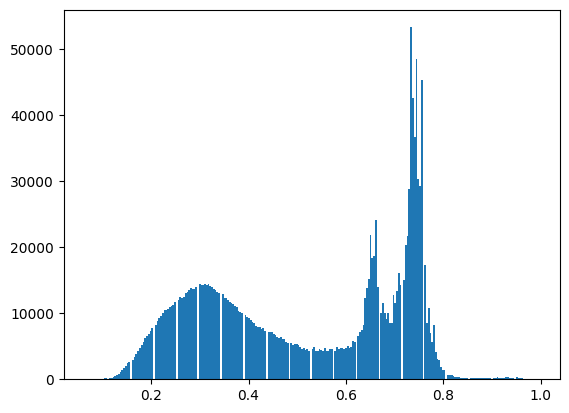

In [32]:
plt.hist(img_norm.flatten(), bins=256)

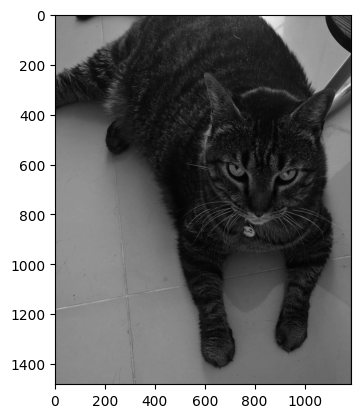

In [33]:
img_gamma1 = img_norm ** 2
plt.imshow(img_gamma1, cmap='gray', vmin=0, vmax=1)

(array([3.8000e+01, 4.2500e+02, 1.3310e+03, 2.5320e+03, 7.6630e+03,
        8.8570e+03, 1.2836e+04, 1.0931e+04, 1.9617e+04, 1.5083e+04,
        2.6298e+04, 1.9666e+04, 2.1047e+04, 2.1501e+04, 2.2263e+04,
        2.3838e+04, 2.4733e+04, 2.5572e+04, 1.3206e+04, 2.7317e+04,
        2.7390e+04, 1.4001e+04, 2.8637e+04, 2.8730e+04, 1.4248e+04,
        2.8511e+04, 1.3933e+04, 2.7215e+04, 1.3237e+04, 2.5977e+04,
        1.2383e+04, 1.2293e+04, 2.3737e+04, 1.1561e+04, 1.1383e+04,
        2.1948e+04, 1.0339e+04, 1.0176e+04, 1.0087e+04, 1.9168e+04,
        9.3150e+03, 8.9880e+03, 8.7190e+03, 1.6503e+04, 7.9710e+03,
        7.9170e+03, 7.5770e+03, 7.7490e+03, 7.3140e+03, 7.1440e+03,
        7.2010e+03, 1.4043e+04, 6.7480e+03, 6.4220e+03, 6.2780e+03,
        6.3850e+03, 6.1210e+03, 6.1560e+03, 5.7000e+03, 5.5400e+03,
        5.4460e+03, 5.2120e+03, 5.3130e+03, 5.3240e+03, 5.1640e+03,
        4.8600e+03, 4.6360e+03, 4.8020e+03, 4.4280e+03, 4.6300e+03,
        4.3570e+03, 0.0000e+00, 4.5870e+03, 4.82

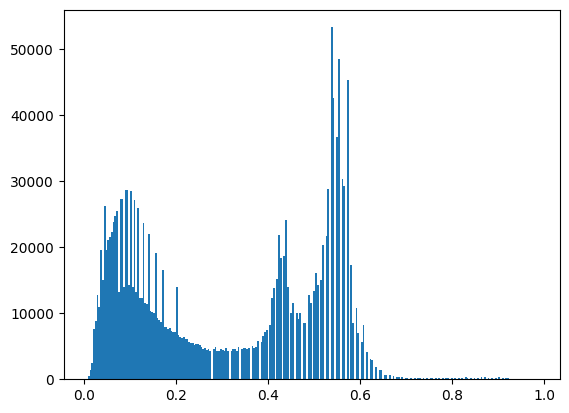

In [34]:
plt.hist(img_gamma1.flatten(), bins=256)

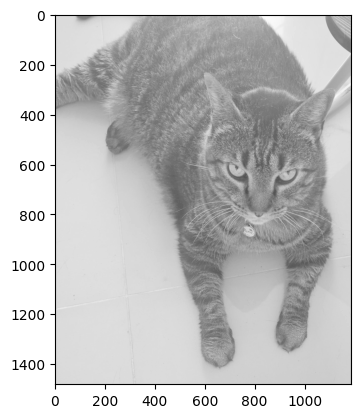

In [35]:
img_gamma2 = img_norm ** 0.5
plt.imshow(img_gamma2, cmap='gray', vmin=0, vmax=1)

(array([2.0000e+00, 0.0000e+00, 3.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 5.0000e+00, 0.0000e+00, 1.0000e+00,
        0.0000e+00, 0.0000e+00, 1.3000e+01, 0.0000e+00, 1.4000e+01,
        0.0000e+00, 2.5000e+01, 0.0000e+00, 0.0000e+00, 3.5000e+01,
        0.0000e+00, 7.5000e+01, 0.0000e+00, 1.2400e+02, 0.0000e+00,
        1.6600e+02, 0.0000e+00, 2.1300e+02, 0.0000e+00, 2.5600e+02,
        0.0000e+00, 3.5900e+02, 0.0000e+00, 5.0300e+02, 0.0000e+00,
        6.4500e+02, 0.0000e+00, 8.2300e+02, 1.0640e+03, 0.0000e+00,
        1.3600e+03, 0.0000e+00, 1.7350e+03, 0.0000e+00, 2.0700e+03,
        0.0000e+00, 2.4980e+03, 2.5660e+03, 0.0000e+00, 2.9440e+03,
        0.0000e+00, 3.3470e+03, 3.7830e+03, 0.0000e+00, 4.2840e+03,
        0.0000e+00, 4.7690e+03, 5.2390e+03, 0.0000e+00, 5.6920e+03,
        6.2490e+03, 0.0000e+00, 6.4850e+03, 0.0000e+00, 6.8830e+03,
        7.2870e+03, 0.0000e+00, 7.7960e+03, 8.2040e+03, 0.0000e+00,
        8.8350e+03, 9.2590e+03, 0.0000e+00, 9.63

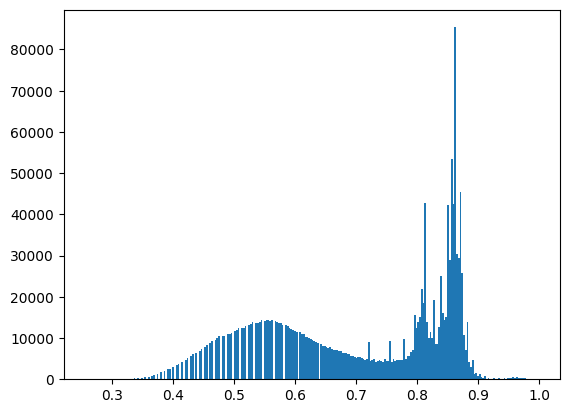

In [36]:
plt.hist(img_gamma2.flatten(), bins=256)